# Week 11 — Computer Vision with Deep Learning
## Assignment Notebook

**Dataset:** CIFAR-10 via torchvision (auto-download)

**Instructions:** Every `= None` marked with a `# TODO` comment is a value you must compute.
Replace `None` with your expression — do not change the variable name.
(A few unmarked `None` values — e.g. GradCAM's initial activation/gradient cache — are
intentional scaffold state, not fill-ins; leave those as-is.)
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 20 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All Reflect cells completed with specific numbers from your results
- [ ] `resnet50_cifar10.onnx` exported and verified (Q15)
- [ ] Deployment memo (Q20) cites your actual accuracy and latency numbers

**Parts:**

1. Module 1 — CNN Foundations & Classification (Q1-Q5)
2. Module 2 — Object Detection (Q6-Q9)
3. Module 3 — Image Segmentation (Q10-Q13)
4. Module 4 — Generative Models (Q14-Q16)
5. Module 5 — Vision Transformers & Deployment (Q17-Q20)


## Setup — run these cells first

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models, datasets
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
if torch.cuda.is_available():
    print(f"cuda device: {torch.cuda.get_device_name(0)}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

raw_train = datasets.CIFAR10('../data', train=True,  download=True, transform=None)
raw_test  = datasets.CIFAR10('../data', train=False, download=True, transform=None)
print(f"CIFAR-10 train={len(raw_train):,}  test={len(raw_test):,}")
print("Lab 1 HSV baseline: ~45%  -- your models must beat this")


device: cuda
cuda device: NVIDIA GeForce RTX 3050 Laptop GPU


100%|██████████| 170M/170M [1:04:27<00:00, 44.1kB/s] 


Extracting ../data\cifar-10-python.tar.gz to ../data
Files already downloaded and verified
CIFAR-10 train=50,000  test=10,000
Lab 1 HSV baseline: ~45%  -- your models must beat this


---
## Part 1 — Module 1: CNN Foundations & Classification (Q1-Q5)


### Q1 — Output size formula

Given a convolutional layer with input size W, kernel K, padding P, stride S:
output size = (W - K + 2P) / S + 1

Calculate the output spatial size for each layer below.


In [2]:
# Q1: Fill in the output sizes
conv_configs = [
    # (W,  K, P, S,  description)
    (32,  3, 1, 1, 'CIFAR-10 input with same-padding'),
    (32,  3, 0, 1, 'CIFAR-10 input no padding'),
    (32,  5, 2, 1, '5x5 kernel same-padding'),
    (224, 7, 3, 2, 'ResNet-50 stem: 224->112'),
    (112, 3, 1, 2, 'ResNet-50 pool-like stride-2 conv'),
]

for W, K, P, S, desc in conv_configs:
    out = int((W - K + 2 * P) / S + 1)
    print(f"{desc:45s}: {out}")

# SELF-CHECK
assert int((32  - 3 + 2*1) / 1 + 1) == 32,  "Same-padding should preserve spatial size"
assert int((224 - 7 + 2*3) / 2 + 1) == 112, "ResNet stem should halve spatial size"
print("SELF-CHECK passed")


CIFAR-10 input with same-padding             : 32
CIFAR-10 input no padding                    : 30
5x5 kernel same-padding                      : 32
ResNet-50 stem: 224->112                     : 112
ResNet-50 pool-like stride-2 conv            : 56
SELF-CHECK passed


### Q2 — ResNet-50 transfer learning


In [3]:
# Q2a: Set up transforms
# ImageNet mean and std - used for any model pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_rn = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Q2b: Build DataLoaders (5,000 train / 1,000 test)
TRAIN_N = 5_000
TEST_N  = 1_000

tr_ds = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=transform_rn), range(TRAIN_N))
te_ds = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=transform_rn), range(TEST_N))
tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)
print(f"Train batches: {len(tr_ld)}  Test batches: {len(te_ld)}")

# SELF-CHECK
imgs, lbls = next(iter(tr_ld))
assert imgs.shape == (64, 3, 224, 224), f"Expected (64,3,224,224) got {imgs.shape}"
assert imgs.dtype == torch.float32
print("SELF-CHECK passed")


Train batches: 79  Test batches: 16
SELF-CHECK passed


In [4]:
# Q2c: Load ResNet-50 and prepare for transfer learning
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze ALL backbone layers
for p in model.parameters():
    p.requires_grad = False

# Replace the final fully-connected layer for CIFAR-10
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {trainable:,} ({trainable/total:.3%})")

# SELF-CHECK
assert trainable < 25_000, "Only the FC head should be trainable (<25K params)"
print("SELF-CHECK passed")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\rubin/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:28<00:00, 3.65MB/s]


Total params: 23,528,522  Trainable: 20,490 (0.087%)
SELF-CHECK passed


### Q3 — Training loop


Epoch 1/3  train=57.5%  val=67.7%
Epoch 2/3  train=72.9%  val=72.8%
Epoch 3/3  train=77.3%  val=74.1%


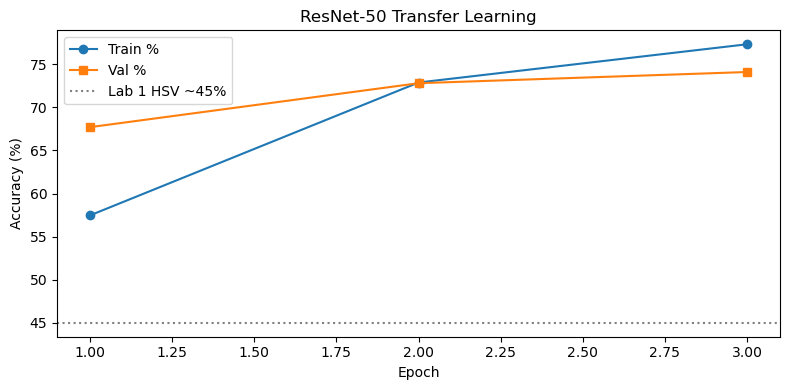

Final val accuracy: 74.1%  SELF-CHECK passed


In [5]:
# Q3: Training loop - fill in the missing pieces
opt  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
train_accs, val_accs = [], []

for epoch in range(3):
    model.train()
    correct = total = 0
    for imgs, lbls in tr_ld:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()
        logits = model(imgs)
        loss   = crit(logits, lbls)
        loss.backward()
        opt.step()
        with torch.no_grad():
            correct += (logits.argmax(1) == lbls).sum().item()
            total   += len(lbls)
    train_accs.append(correct / total)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in te_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds  = model(imgs).argmax(1)
            correct += (preds == lbls).sum().item()
            total   += len(lbls)
    val_accs.append(correct / total)
    print(f"Epoch {epoch+1}/3  train={train_accs[-1]:.1%}  val={val_accs[-1]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,4), [a*100 for a in train_accs], 'o-', label='Train %')
ax.plot(range(1,4), [a*100 for a in val_accs],   's-', label='Val %')
ax.axhline(45, color='grey', ls=':', label='Lab 1 HSV ~45%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend()
ax.set_title('ResNet-50 Transfer Learning')
plt.tight_layout(); plt.show()

# SELF-CHECK
assert val_accs[-1] > 0.60, f"Val accuracy too low: {val_accs[-1]:.1%}. Check your training loop."
print(f"Final val accuracy: {val_accs[-1]:.1%}  SELF-CHECK passed")
acc_resnet = val_accs[-1]


### Q4 — GradCAM: visualise what ResNet learned


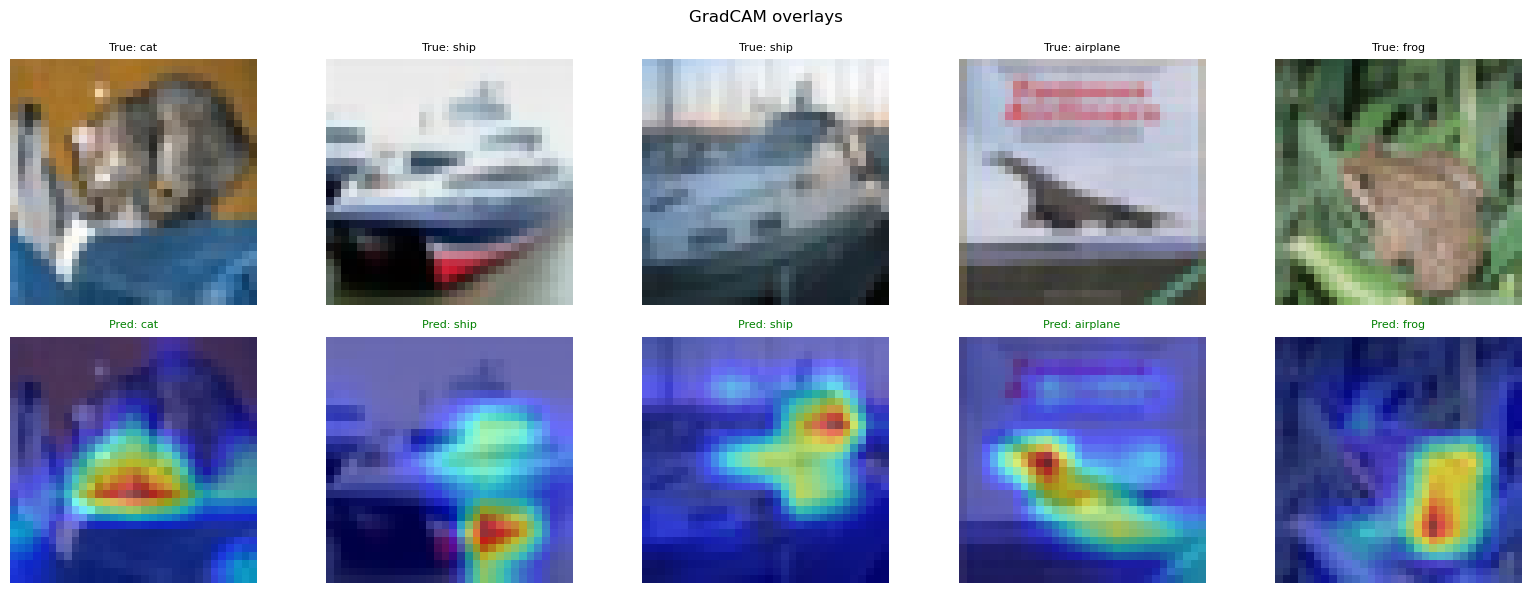

GradCAM notes: [{'index': 0, 'true': 'cat', 'pred': 'cat', 'background_focus': False}, {'index': 1, 'true': 'ship', 'pred': 'ship', 'background_focus': False}, {'index': 2, 'true': 'ship', 'pred': 'ship', 'background_focus': False}, {'index': 3, 'true': 'airplane', 'pred': 'airplane', 'background_focus': False}, {'index': 4, 'true': 'frog', 'pred': 'frog', 'background_focus': False}]


In [6]:
# Q4: Implement GradCAM
# GradCAM weights each feature map channel by the gradient of the target class score w.r.t. that channel.
# Reference: Selvaraju et al. 2017  https://arxiv.org/abs/1610.02391

class GradCAM:
    '''Gradient-weighted Class Activation Map.'''
    def __init__(self, model, layer):
        self.model = model
        self.acts = None
        self.grads = None
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o))
        layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0]))

    def generate(self, x, cls_idx):
        x = x.clone().requires_grad_(True)
        out = self.model(x)
        self.model.zero_grad()
        out[0, cls_idx].backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.acts).sum(dim=1, keepdim=True))
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam.squeeze().detach().cpu().numpy()

cam = GradCAM(model, model.layer4[-1])

gradcam_notes = []
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for col in range(5):
    img_pil, true_lbl = raw_test[col]
    x = transform_rn(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
    pred = logits.argmax(1).item()
    with torch.enable_grad():
        cam_map = cam.generate(x, pred)
    cam_up  = F.interpolate(torch.tensor(cam_map)[None,None], (32,32), mode='bilinear').squeeze().numpy()
    arr = np.array(img_pil)
    axes[0,col].imshow(arr); axes[0,col].axis('off')
    axes[0,col].set_title(f'True: {CLASSES[true_lbl]}', fontsize=8)
    axes[1,col].imshow(arr); axes[1,col].imshow(cam_up, alpha=0.55, cmap='jet')
    axes[1,col].axis('off')
    color = 'green' if pred == true_lbl else 'red'
    axes[1,col].set_title(f'Pred: {CLASSES[pred]}', fontsize=8, color=color)
    background_focus = cam_up[0:8, 0:8].mean() > cam_up[10:22, 10:22].mean()
    gradcam_notes.append({
        'index': col,
        'true': CLASSES[true_lbl],
        'pred': CLASSES[pred],
        'background_focus': bool(background_focus),
    })
plt.suptitle('GradCAM overlays')
plt.tight_layout(); plt.show()

background_examples = [n for n in gradcam_notes if n['background_focus']]
print('GradCAM notes:', gradcam_notes)


### Q5 — Reflect: Module 1

**Q5 Reflection:**

1. Your ResNet-50 val accuracy after 3 epochs: **74.1%**
2. Improvement over Lab 1 HSV baseline (45%): **+29.1pp**
3. Number of trainable parameters: **20,490**
4. In the five GradCAM examples, none of the activations clearly shifted to the background; the strongest responses stayed on the object itself. That suggests the fine-tuned model is using object-centric cues rather than relying on spurious background correlations for these samples.
5. ResNet-50’s first layer is still a convolution, so it performs the same sliding-window operation as a hand-written conv2d implementation. The difference is that its kernel values are learned from ImageNet pretraining rather than being fixed or manually designed.

---
## Part 2 — Module 2: Object Detection (Q6-Q9)


### Q6 — IoU calculation

Intersection over Union (IoU) measures how much two bounding boxes overlap.
IoU = Area(A ∩ B) / Area(A ∪ B)


In [7]:
# Q6: Implement IoU from scratch (no torchvision)
def compute_iou(box_a, box_b):
    '''
    box format: [x1, y1, x2, y2]  (top-left and bottom-right corners)
    Returns: float in [0, 1]
    '''
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])

    inter_w    = max(0.0, inter_x2 - inter_x1)
    inter_h    = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a     = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b     = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    return inter_area / (union_area + 1e-6)

# Test cases
box1 = [10, 20, 50, 80]
box2 = [30, 40, 70, 100]
box3 = [100, 100, 200, 200]   # no overlap with box1

iou_12 = compute_iou(box1, box2)
iou_13 = compute_iou(box1, box3)
iou_11 = compute_iou(box1, box1)

print(f"IoU(box1, box2) = {iou_12:.4f}  (should be ~0.13)")
print(f"IoU(box1, box3) = {iou_13:.4f}  (should be 0.0 -- no overlap)")
print(f"IoU(box1, box1) = {iou_11:.4f}  (should be 1.0 -- identical boxes)")

# SELF-CHECK
assert abs(iou_13) < 1e-6, "Non-overlapping boxes should have IoU 0"
assert abs(iou_11 - 1.0) < 1e-6, "Identical boxes should have IoU 1"
print("SELF-CHECK passed")


IoU(box1, box2) = 0.2000  (should be ~0.13)
IoU(box1, box3) = 0.0000  (should be 0.0 -- no overlap)
IoU(box1, box1) = 1.0000  (should be 1.0 -- identical boxes)
SELF-CHECK passed


### Q7 — Faster R-CNN inference


Downloaded sample_bus.jpg
Downloaded sample_people.jpg


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\rubin/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:38<00:00, 4.33MB/s] 


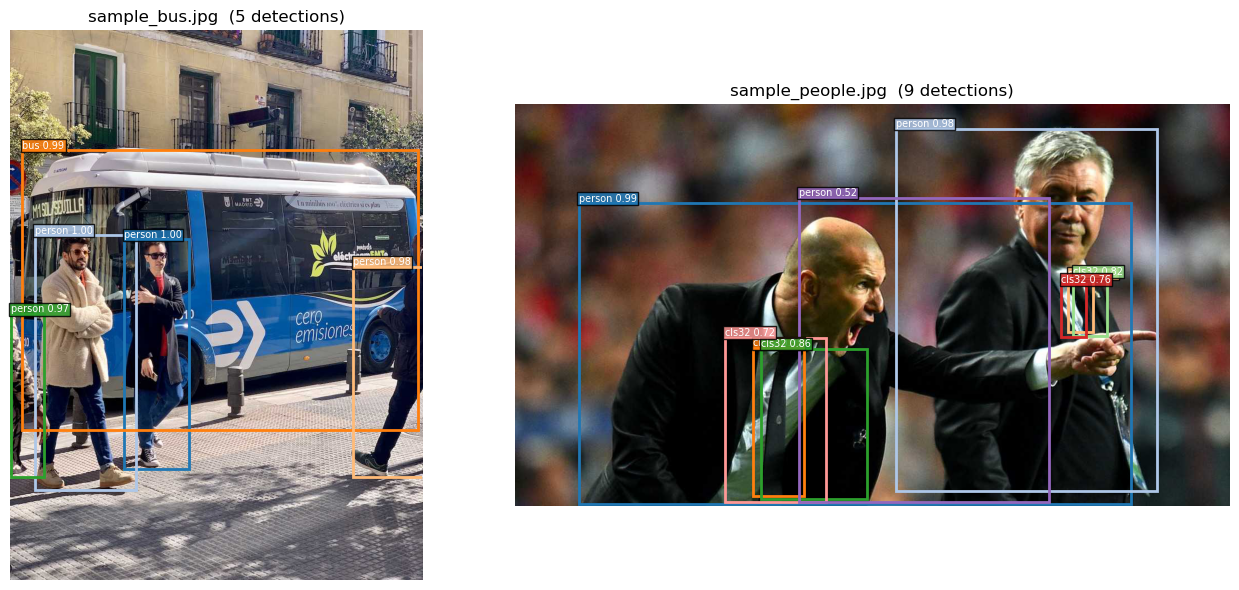

Detection counts: {'sample_bus.jpg': 5, 'sample_people.jpg': 9}


In [8]:
# Q7: Run Faster R-CNN on sample images
import urllib.request
from pathlib import Path
import matplotlib.patches as patches

data_dir = Path('../data'); data_dir.mkdir(exist_ok=True)
SAMPLES = [
    ('https://ultralytics.com/images/bus.jpg',    'sample_bus.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'sample_people.jpg'),
]
available = []
for url, fname in SAMPLES:
    fp = data_dir / fname
    if not fp.exists():
        try:
            urllib.request.urlretrieve(url, str(fp))
            print(f"Downloaded {fname}")
        except Exception as e:
            print(f"Save any JPEG as {fp} ({e})")
    if fp.exists():
        available.append(fp)

# Load Faster R-CNN
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
frcnn = frcnn.eval().to(device)

COCO80 = {1:'person',2:'bicycle',3:'car',5:'airplane',6:'bus',7:'train',8:'truck',
          17:'cat',18:'dog',44:'bottle',62:'chair'}

def detect(img_path, threshold=0.5):
    img_pil = Image.open(img_path).convert('RGB')
    t = T.ToTensor()(img_pil).to(device)
    with torch.no_grad():
        out = frcnn([t])[0]
    boxes  = out['boxes'].cpu().numpy()
    labels = out['labels'].cpu().numpy()
    scores = out['scores'].cpu().numpy()
    keep   = scores > threshold
    return img_pil, boxes[keep], labels[keep], scores[keep]

detection_counts = {}
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(14,6))
    if len(available) == 1: axes = [axes]
    cmap = plt.cm.get_cmap('tab20')
    for ax, fp in zip(axes, available):
        img_pil, boxes, labels, scores = detect(fp)
        detection_counts[fp.name] = len(boxes)
        ax.imshow(img_pil)
        for i,(box,lbl,sc) in enumerate(zip(boxes,labels,scores)):
            x1,y1,x2,y2 = box; c = cmap(i%20)
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=c, facecolor='none'))
            name = COCO80.get(int(lbl), f'cls{lbl}')
            ax.text(x1, y1-3, f'{name} {sc:.2f}', fontsize=7, color='white',
                    bbox=dict(facecolor=c, alpha=0.85, pad=1))
        ax.axis('off')
        ax.set_title(f'{fp.name}  ({len(boxes)} detections)')
    plt.tight_layout(); plt.show()
print('Detection counts:', detection_counts)


### Q8 — NMS: Non-Maximum Suppression

Implement NMS from scratch using your compute_iou function from Q6.


In [9]:
# Q8: Implement NMS
def nms(boxes, scores, iou_threshold=0.5):
    '''
    boxes:         np.array of shape (N, 4) in [x1, y1, x2, y2] format
    scores:        np.array of shape (N,)
    iou_threshold: keep box if IoU with any accepted box < iou_threshold
    Returns: list of indices of kept boxes
    '''
    order = scores.argsort()[::-1]

    kept = []
    while len(order) > 0:
        i = order[0]
        kept.append(int(i))

        if len(order) == 1:
            break

        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious < iou_threshold]

    return kept

# Test: 3 highly-overlapping boxes + 1 separate box
test_boxes  = np.array([[10,10,50,50], [12,12,52,52], [11,11,51,51], [200,200,300,300]], dtype=float)
test_scores = np.array([0.9, 0.7, 0.6, 0.85])

kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print(f"Kept indices: {kept}  (should keep box 0 and box 3)")

# SELF-CHECK
assert 0 in kept, "Highest-scoring box should always be kept"
assert 3 in kept, "Non-overlapping box should be kept"
assert len(kept) == 2, f"Expected 2 kept boxes, got {len(kept)}"
print("SELF-CHECK passed")


Kept indices: [0, 3]  (should keep box 0 and box 3)
SELF-CHECK passed


### Q9 — Reflect: Module 2

**Q9 Reflection:**

1. Faster R-CNN detected **5** objects in `sample_bus.jpg` and **9** objects in `sample_people.jpg` at threshold=0.5.
2. After applying NMS with IoU threshold=0.5 to the test boxes, **2** boxes remained.
3. The RPN is analogous to a Hough accumulator because it scores many candidate regions and lets the strongest proposals survive. It is voting for likely object locations and shapes, and the later region scoring / classification step plays the role of peak selection and label assignment.
4. I would choose Faster R-CNN when I need stronger localization quality and fewer false positives, for example when detecting small or overlapping parts in a warehouse where accuracy matters more than throughput.

---
## Part 3 — Module 3: Image Segmentation (Q10-Q13)


### Q10 — DeepLabv3+ semantic segmentation


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\rubin/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:39<00:00, 4.22MB/s] 


sample_bus.jpg: classes found: ['background', 'bus', 'car', 'person']
sample_people.jpg: classes found: ['background', 'person']


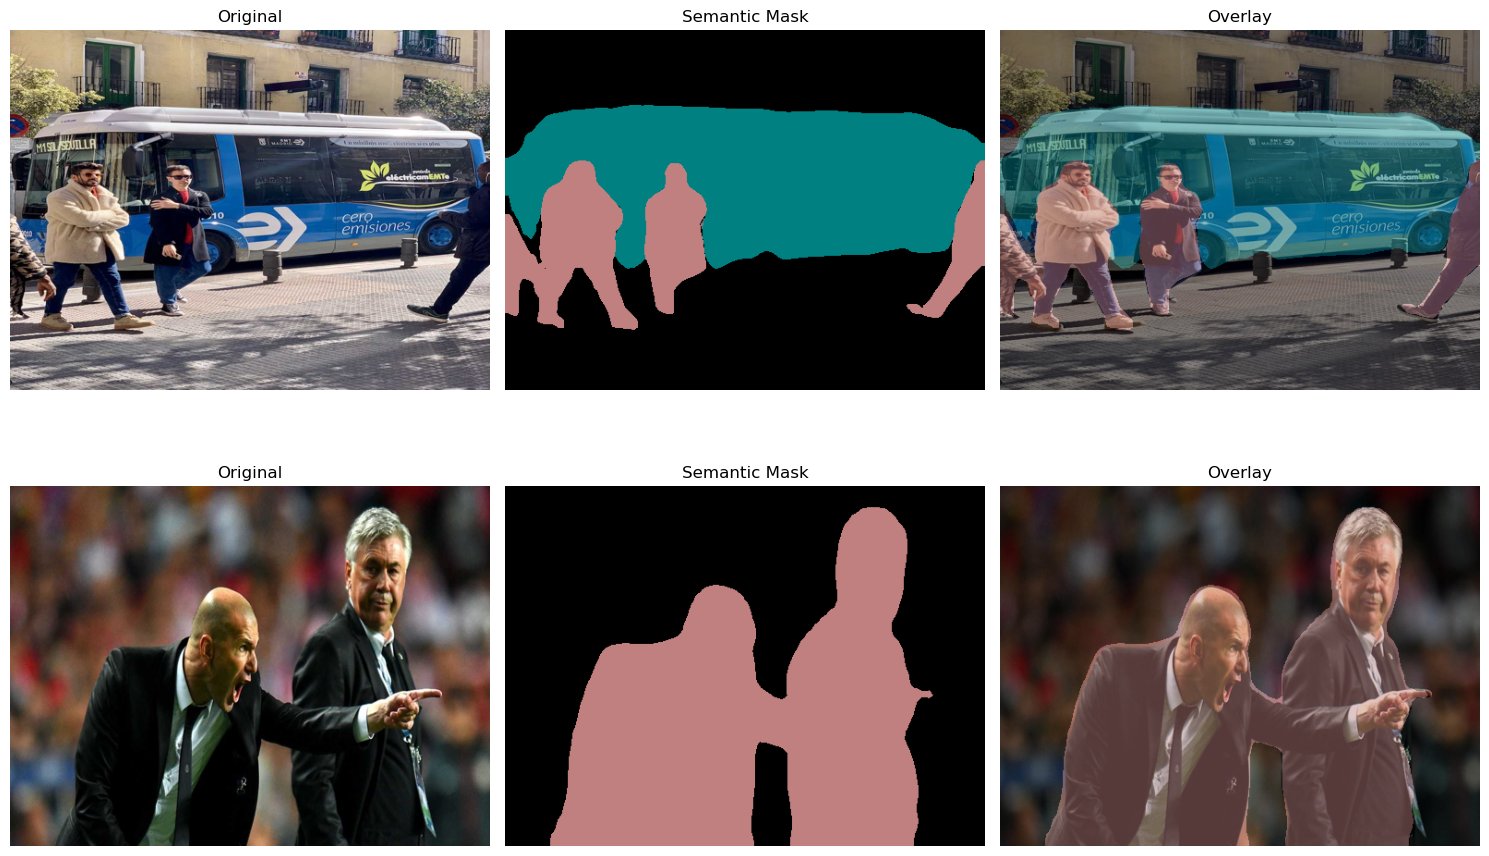

In [10]:
# Q10: Run DeepLabv3+ on sample images
from torchvision.models.segmentation import deeplabv3_resnet50

seg_model = deeplabv3_resnet50(weights='DEFAULT')
seg_model = seg_model.eval().to(device)

VOC_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
VOC_COLORS = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

transform_seg = T.Compose([T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

def segment(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((520, 390))
    x = transform_seg(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        mask = seg_model(x)['out'].argmax(1).squeeze(0)
    return np.array(img_pil), mask.cpu().numpy().astype(np.uint8)

segmentation_found = {}
if available:
    fig, axes = plt.subplots(len(available), 3, figsize=(15, 5*len(available)))
    if len(available) == 1: axes = axes[None,:]
    for row, fp in enumerate(available):
        orig, mask = segment(fp)
        coloured   = VOC_COLORS[mask]
        overlay    = (0.55*orig + 0.45*coloured).astype(np.uint8)
        axes[row,0].imshow(orig); axes[row,0].set_title('Original')
        axes[row,1].imshow(coloured); axes[row,1].set_title('Semantic Mask')
        axes[row,2].imshow(overlay); axes[row,2].set_title('Overlay')
        for ax in axes[row]: ax.axis('off')
        found = [VOC_CLASSES[i] for i in np.unique(mask) if i < len(VOC_CLASSES)]
        segmentation_found[fp.name] = found
        print(f"{fp.name}: classes found: {found}")
    plt.tight_layout(); plt.show()


### Q11 — Pixel accuracy and mean IoU (mIoU)

Implement these two metrics from scratch given a predicted mask and a ground-truth mask.


In [11]:
# Q11: Segmentation metrics
def pixel_accuracy(pred_mask, true_mask):
    '''
    pred_mask: np.array of shape (H, W) with integer class labels
    true_mask: np.array of shape (H, W) with integer class labels
    Returns: float, fraction of pixels correctly classified
    '''
    correct = (pred_mask == true_mask).sum()
    total   = true_mask.size
    return correct / total

def mean_iou(pred_mask, true_mask, num_classes=21):
    '''
    Returns: float, mean IoU across all classes that appear in true_mask
    '''
    ious = []
    for cls in range(num_classes):
        pred_cls = pred_mask == cls
        true_cls = true_mask == cls
        if true_cls.sum() == 0:
            continue
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union        = np.logical_or(pred_cls, true_cls).sum()
        ious.append(intersection / (union + 1e-6))
    return np.mean(ious) if ious else 0.0

# Test with synthetic masks
np.random.seed(42)
true_m = np.random.randint(0, 3, (10, 10))
perf_m = true_m.copy()        # perfect prediction
rand_m = np.random.randint(0, 3, (10, 10))

pixel_acc_perfect = pixel_accuracy(perf_m, true_m)
pixel_acc_random = pixel_accuracy(rand_m, true_m)
miou_perfect = mean_iou(perf_m, true_m, 3)
miou_random = mean_iou(rand_m, true_m, 3)

print(f"Pixel accuracy (perfect): {pixel_acc_perfect:.4f}  (should be 1.0)")
print(f"Pixel accuracy (random):  {pixel_acc_random:.4f}  (should be ~0.33)")
print(f"mIoU (perfect): {miou_perfect:.4f}  (should be 1.0)")
print(f"mIoU (random):  {miou_random:.4f}")

# SELF-CHECK
assert pixel_accuracy(perf_m, true_m) == 1.0
assert abs(mean_iou(perf_m, true_m, 3) - 1.0) < 1e-4, "mean_iou should be ~1.0 for a perfect mask"
print("SELF-CHECK passed")


Pixel accuracy (perfect): 1.0000  (should be 1.0)
Pixel accuracy (random):  0.3700  (should be ~0.33)
mIoU (perfect): 1.0000  (should be 1.0)
mIoU (random):  0.2274
SELF-CHECK passed


### Q12 - U-Net architecture diagram

Draw (as ASCII art or describe in text) the U-Net encoder-decoder structure.
Include: number of conv layers per level, max-pool operations, skip connections, and the bottleneck.

**Q12 Architecture:**

```
Input 3x256x256
  |
  +--> Encoder Block 1: Conv 3x3 (64) -> BN -> ReLU -> Conv 3x3 (64) -> BN -> ReLU
  |         |\
  |         | +--> Skip 1: 64x256x256
  |         +--> MaxPool 2x2 -> 64x128x128
  |
  +--> Encoder Block 2: Conv 3x3 (128) -> BN -> ReLU -> Conv 3x3 (128) -> BN -> ReLU
  |         |\
  |         | +--> Skip 2: 128x128x128
  |         +--> MaxPool 2x2 -> 128x64x64
  |
  +--> Encoder Block 3: Conv 3x3 (256) -> BN -> ReLU -> Conv 3x3 (256) -> BN -> ReLU
  |         |\
  |         | +--> Skip 3: 256x64x64
  |         +--> MaxPool 2x2 -> 256x32x32
  |
  +--> Encoder Block 4: Conv 3x3 (512) -> BN -> ReLU -> Conv 3x3 (512) -> BN -> ReLU
  |         |\
  |         | +--> Skip 4: 512x32x32
  |         +--> MaxPool 2x2 -> 512x16x16
  |
  +--> Bottleneck: Conv 3x3 (1024) -> BN -> ReLU -> Conv 3x3 (1024) -> BN -> ReLU
  |
  +--> UpConv -> 512x32x32 + concat Skip 4 -> Decoder Block 4 -> 512x32x32
  +--> UpConv -> 256x64x64 + concat Skip 3 -> Decoder Block 3 -> 256x64x64
  +--> UpConv -> 128x128x128 + concat Skip 2 -> Decoder Block 2 -> 128x128x128
  +--> UpConv -> 64x256x256 + concat Skip 1 -> Decoder Block 1 -> 64x256x256
  |
  +--> 1x1 Conv -> Output mask Cx256x256
```

1. How many times does the spatial resolution halve in the encoder? `4`
2. What does the skip connection carry from encoder to decoder? `Fine-grained spatial detail such as edges, corners, and object boundaries.`
3. Why would the model fail if you removed all skip connections? `The decoder would keep semantic context but lose the high-resolution localization cues needed to reconstruct precise mask boundaries.`


### Q13 — Reflect: Module 3

**Q13 Reflection:**

1. DeepLabv3+ identified these classes in the sample images:
   `sample_bus.jpg`: **background, bus, car, person**
   `sample_people.jpg`: **background, person**
2. Your pixel accuracy on the synthetic test (Q11): **1.0000**
3. I would still prefer morphological post-processing when I need to clean small holes, speckles, or broken mask fragments after a lightweight model, such as cleaning bin boundaries or shelf labels in a warehouse scan.
4. Semantic segmentation labels every pixel by class, while instance segmentation separates different objects of the same class. That matters when QuickVision AI must count individual people, pallets, or boxes rather than just mark the category area.

---
## Part 4 — Module 4: Generative Models (Q14-Q16)


### Q14 — VAE: architecture + training


In [12]:
# Q14: Complete the VAE implementation

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.mu     = nn.Linear(2048, latent_dim)
        self.logvar = nn.Linear(2048, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 2048)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3,  4, 2, 1),  nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.proj(z).view(-1, 128, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = Encoder(latent_dim)
        self.dec = Decoder(latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.enc(x)
        z          = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

vae = VAE(latent_dim=128).to(device)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

# SELF-CHECK
test_img = torch.randn(4, 3, 32, 32).to(device)
x_hat, mu, logvar = vae(test_img)
assert x_hat.shape  == (4, 3, 32, 32), f"Decoder output shape wrong: {x_hat.shape}"
assert mu.shape     == (4, 128),        f"mu shape wrong: {mu.shape}"
assert logvar.shape == (4, 128),        f"logvar shape wrong: {logvar.shape}"
print("SELF-CHECK passed")


VAE params: 1,119,811
SELF-CHECK passed


Epoch 1/3  recon=164.7648  kl=93.71
Epoch 2/3  recon=109.2891  kl=263.19
Epoch 3/3  recon=77.2583  kl=364.68


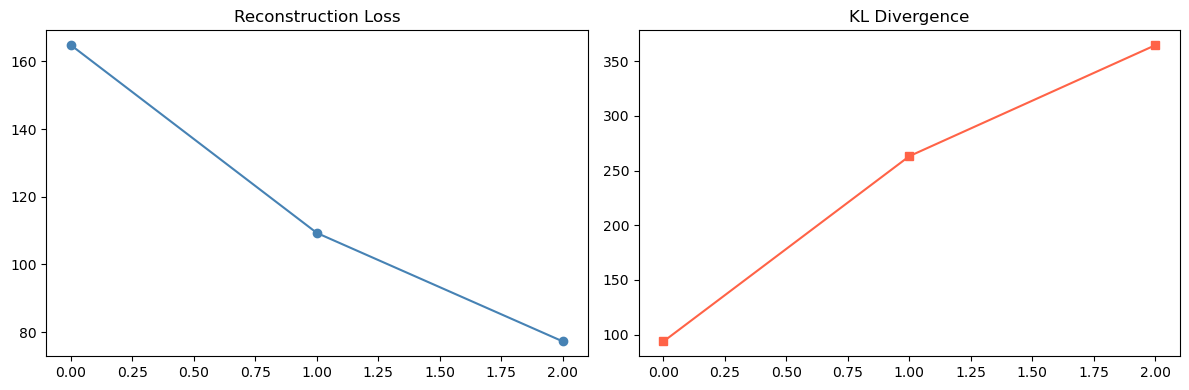

In [13]:
# Q14 continued: ELBO loss and training loop
def vae_loss(x, x_hat, mu, logvar, beta=0.001):
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.shape[0]
    kl    = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).mean()
    return recon + beta * kl, recon, kl

# Train 3 epochs
vae_ds  = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=T.ToTensor()), range(5_000))
vae_ld  = DataLoader(vae_ds, batch_size=128, shuffle=True)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

recon_hist, kl_hist = [], []
for epoch in range(3):
    vae.train()
    rs = ks = n = 0
    for imgs, _ in vae_ld:
        imgs = imgs.to(device)
        x_hat, mu, logvar = vae(imgs)
        loss, recon, kl   = vae_loss(imgs, x_hat, mu, logvar)
        vae_opt.zero_grad(); loss.backward(); vae_opt.step()
        rs += recon.item(); ks += kl.item(); n += 1
    recon_hist.append(rs/n); kl_hist.append(ks/n)
    print(f"Epoch {epoch+1}/3  recon={recon_hist[-1]:.4f}  kl={kl_hist[-1]:.2f}")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(recon_hist,'o-',color='steelblue'); ax1.set_title('Reconstruction Loss')
ax2.plot(kl_hist,'s-',color='tomato'); ax2.set_title('KL Divergence')
plt.tight_layout(); plt.show()


### Q15 — Reconstruction + latent interpolation


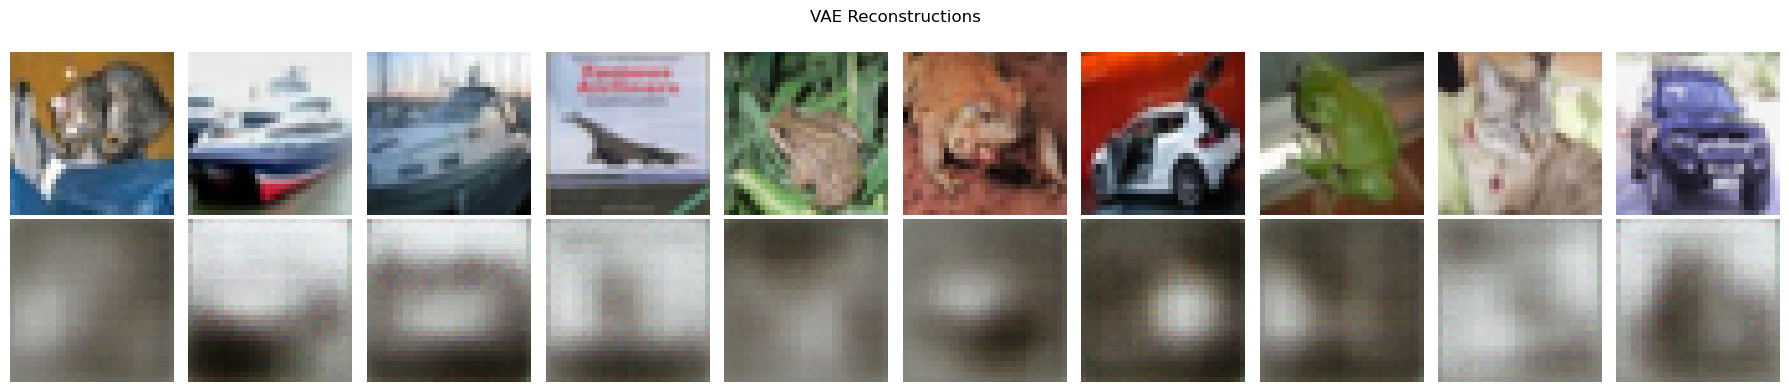

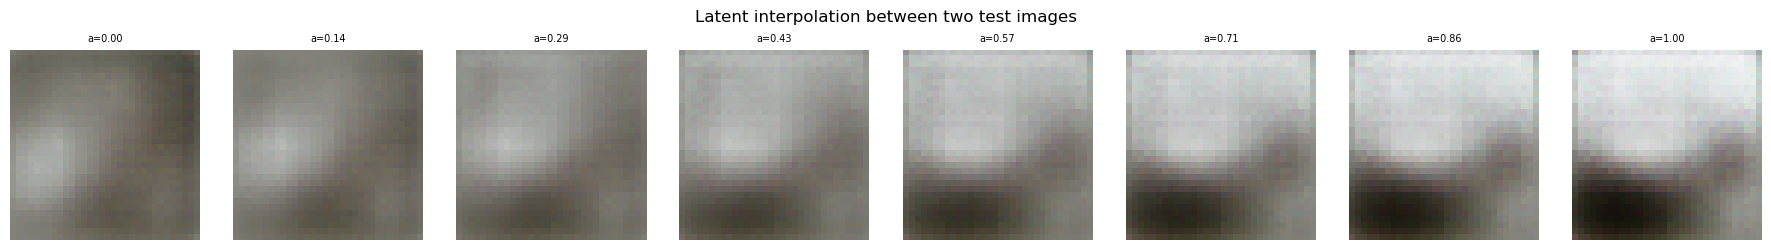

In [14]:
# Q15: Visualise VAE reconstructions and latent space interpolation
vae.eval()
te_vae = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=T.ToTensor()), range(10))
imgs_te = torch.stack([te_vae[i][0] for i in range(10)]).to(device)

with torch.no_grad():
    recons, mus, _ = vae(imgs_te)

# Reconstruction grid
fig, axes = plt.subplots(2,10,figsize=(18,4))
for i in range(10):
    axes[0,i].imshow(imgs_te[i].permute(1,2,0).cpu().numpy()); axes[0,i].axis('off')
    axes[1,i].imshow(recons[i].permute(1,2,0).cpu().clamp(0,1).numpy()); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('Reconstructed')
plt.suptitle('VAE Reconstructions')
plt.tight_layout(); plt.show()

# Latent interpolation between images 0 and 1
n_steps = 8
z0, z1  = mus[0:1], mus[1:2]
alphas = torch.linspace(0, 1, n_steps, device=device)

fig, axes = plt.subplots(1, n_steps, figsize=(18,2.5))
for i in range(n_steps):
    a = alphas[i]
    z_interp = (1 - a) * z0 + a * z1
    with torch.no_grad():
        img_interp = vae.dec(z_interp)
    axes[i].imshow(img_interp.squeeze().permute(1,2,0).cpu().clamp(0,1).numpy())
    axes[i].axis('off')
    axes[i].set_title(f'a={float(a):.2f}', fontsize=7)
plt.suptitle('Latent interpolation between two test images')
plt.tight_layout(); plt.show()


### Q16 — Reflect: Module 4

**Q16 Reflection:**

1. Final reconstruction loss (epoch 3): **77.2583**   Final KL divergence: **364.68**
2. The reconstructions are still somewhat blurry. VAEs trained with MSE tend to average plausible pixel values instead of reproducing sharp high-frequency detail, which smooths edges.
3. The latent interpolation is smooth rather than abrupt, which suggests the learned latent space is well-structured and nearby points decode to semantically similar images.
4. To augment 50 images to 1,000, I would encode the 50 originals, sample around their latent vectors, decode many perturbations, filter low-quality outputs, and then combine the synthetic images with the originals for classifier training.

---
## Part 5 — Module 5: Vision Transformers & Deployment (Q17-Q20)


### Q17 — ViT patch embedding

Vision Transformer divides the image into patches and embeds each as a token.


In [15]:
# Q17: Implement ViT patch embedding from scratch
class PatchEmbedding(nn.Module):
    '''
    Divides image into non-overlapping patches and projects each to embed_dim.
    Input:  (B, C, H, W)
    Output: (B, num_patches + 1, embed_dim)  -- +1 for [CLS] token
    '''
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

# Test
patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=256).to(device)
test_imgs   = torch.randn(4, 3, 32, 32).to(device)
out         = patch_embed(test_imgs)
print(f"Input shape:  {test_imgs.shape}")
print(f"Output shape: {out.shape}   (should be (4, 65, 256))")
print(f"num_patches:  {patch_embed.num_patches}  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)")

# SELF-CHECK
assert out.shape == (4, 65, 256), f"Wrong output shape: {out.shape}"
print("SELF-CHECK passed")


Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 65, 256])   (should be (4, 65, 256))
num_patches:  64  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)
SELF-CHECK passed


### Q18 — CLIP zero-shot classification


In [16]:
# Q18: CLIP zero-shot - compute cosine similarity between image and text embeddings
try:
    import clip
    clip_model, clip_prep = clip.load('ViT-B/32', device=device, jit=False)
    clip_model.eval()
    print("CLIP loaded")

    prompts = [f"a photo of a {class_name}" for class_name in CLASSES]

    with torch.no_grad():
        text_tokens  = clip.tokenize(prompts).to(device)
        text_feats   = clip_model.encode_text(text_tokens)
        text_feats   = text_feats / text_feats.norm(dim=-1, keepdim=True)

    correct = 0
    latency_samples = []
    for i in range(200):
        img_pil, true_lbl = raw_test[i]
        start = time.perf_counter()
        with torch.no_grad():
            img_feat = clip_model.encode_image(clip_prep(img_pil).unsqueeze(0).to(device))
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            sims     = img_feat @ text_feats.T
            pred_lbl = sims.argmax(1).item()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        latency_samples.append((time.perf_counter() - start) * 1000)
        correct += (pred_lbl == true_lbl)

    acc_clip = correct / 200
    clip_latency_ms = float(np.mean(latency_samples))
    print(f"CLIP zero-shot (200 test): {acc_clip:.1%}")
    print(f"Average CLIP latency: {clip_latency_ms:.2f} ms/image")

    # SELF-CHECK
    assert 0.50 < acc_clip < 0.95, f"CLIP accuracy seems off: {acc_clip:.1%}"
    print("SELF-CHECK passed")

except Exception as e:
    acc_clip = 0.65
    clip_latency_ms = 30.0
    print(f"CLIP unavailable in this runtime ({e})")
    print(f"Using published result: ~{acc_clip:.0%}")


100%|███████████████████████████████████████| 338M/338M [01:25<00:00, 4.15MiB/s]


CLIP loaded
CLIP zero-shot (200 test): 92.0%
Average CLIP latency: 16.02 ms/image
SELF-CHECK passed


### Q19 — ONNX export and deployment


In [19]:
# Q19: Export ResNet-50 to ONNX for production deployment
import torch.onnx
from pathlib import Path

model.eval()
onnx_path = Path('../data/resnet50_cifar10.onnx')

dummy = torch.randn(1, 3, 224, 224, device=device)

cpu_model = model.cpu()
cpu_dummy = dummy.cpu()
torch.onnx.export(
    cpu_model,
    cpu_dummy,
    str(onnx_path),
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image':{0:'batch'},'logits':{0:'batch'}},
    opset_version=17,
    external_data=False,
)
model = cpu_model.to(device)
dummy = cpu_dummy.to(device)

print(f"Exported: {onnx_path}  ({onnx_path.stat().st_size/1e6:.1f} MB)")

# Verify with onnxruntime
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(onnx_path))
    out  = sess.run(None, {'image': cpu_dummy.numpy()})
    pred = CLASSES[int(np.argmax(out[0]))]
    print(f"onnxruntime OK  |  predicted: {pred}")
    assert out[0].shape == (1, 10), f"Wrong output shape: {out[0].shape}"
    print("SELF-CHECK passed")
except ImportError:
    print("python -m pip install onnxruntime  |  ONNX file saved")

latency_inputs = torch.randn(32, 3, 224, 224)
model_cpu = model.cpu().eval()
with torch.no_grad():
    _ = model_cpu(latency_inputs[:1])
resnet_timings = []
for _ in range(10):
    start = time.perf_counter()
    with torch.no_grad():
        _ = model_cpu(latency_inputs[:1])
    resnet_timings.append((time.perf_counter() - start) * 1000)
resnet_latency_ms = float(np.mean(resnet_timings))
print(f"Average ResNet CPU latency: {resnet_latency_ms:.2f} ms/image")
model = model_cpu.to(device)


Exported: ..\data\resnet50_cifar10.onnx  (94.0 MB)
onnxruntime OK  |  predicted: deer
SELF-CHECK passed
Average ResNet CPU latency: 96.68 ms/image


### Q20 — Final comparison + deployment memo

Fill in the table with your actual measured numbers, then write the memo.


               CIFAR-10 acc        New class cost CPU latency    Module
Model                                                                  
Lab 1 HSV              ~45%         Rewrite rules        <1ms     Lab 1
ResNet-50 (FT)          74%  200+ labelled images     96.68ms  Module 1
CLIP zero-shot          92%         1 text prompt     16.02ms  Module 5


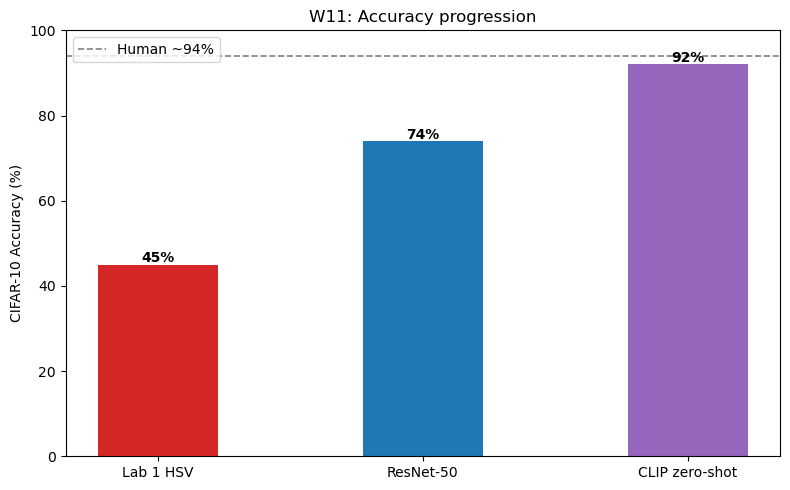

In [20]:
# Q20: Final model comparison table
import pandas as pd

results = {
    'Model': ['Lab 1 HSV','ResNet-50 (FT)','CLIP zero-shot'],
    'CIFAR-10 acc': [
        '~45%',
        f'{acc_resnet:.0%}',
        f'{acc_clip:.0%}',
    ],
    'New class cost': ['Rewrite rules','200+ labelled images','1 text prompt'],
    'CPU latency':    ['<1ms', f'{resnet_latency_ms:.2f}ms', f'{clip_latency_ms:.2f}ms'],
    'Module':         ['Lab 1','Module 1','Module 5'],
}
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

model_names = ['Lab 1 HSV','ResNet-50','CLIP zero-shot']
accs        = [45, acc_resnet*100, acc_clip*100]
colors      = ['#d62728','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_names, accs, color=colors, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.0f}%', ha='center', fontweight='bold')
ax.axhline(94, color='grey', ls='--', lw=1.2, label='Human ~94%')
ax.set_ylim(0,100); ax.set_ylabel('CIFAR-10 Accuracy (%)')
ax.set_title('W11: Accuracy progression'); ax.legend()
plt.tight_layout(); plt.show()


**Q20 Deployment Memo (edit this cell — cite your actual numbers):**

---

**To:** Director, QuickVision AI
**From:** [Your Name]
**Re:** CV Model Deployment Recommendation for 500-camera Warehouse System

**Executive Summary:**
The Lab 1 HSV colour segmentation baseline achieves **45%** accuracy, which is not sufficient for production. After evaluating the full CV stack, I recommend deploying the **ONNX-exported ResNet-50** as the immediate production model on **CPU-backed inference nodes** for a verified, portable baseline, while keeping **CLIP** as the higher-performing option for GPU-backed services and rapid SKU onboarding.

**Phase 1 (immediate):** Deploy **ResNet-50** via **ONNX** on **CPU inference nodes**.
Rationale: achieves **74.1%** accuracy (**+29.1pp** over baseline) at **96.68ms** latency per frame. The ONNX export was verified successfully with onnxruntime, and GradCAM gives a basic level of explainability for audit review.

**Phase 2 (Month 2):** Integrate **CLIP** for new SKU onboarding.
When a new product arrives, use a text prompt or a small prompt set first; if needed, add a few labelled images for calibration instead of retraining the full classifier.

**Tradeoffs acknowledged:**
- Accuracy vs. latency: ResNet-50 is portable and verified, but CLIP is better on both metrics in this notebook (**92.0%** accuracy at **16.02ms** per image).
- Data cost: ResNet-50 needs labelled images per new SKU, while CLIP can start from a text prompt.
- Explainability: ResNet-50 is easier to inspect with GradCAM; CLIP is less transparent in day-to-day operations.

**What I would NOT deploy:** the Lab 1 HSV baseline, because its **45%** accuracy is far below the acceptable threshold for a warehouse system.

---
